# Seminar: ConvNeXt + CAPTCHA (5 символов, multilabel)

### Постановка задачи

- CAPTCHA = 5 символов
- Алфавит: 0-9a-z (36 классов)
- Выход модели:
  - (batch, 5, 36)

### Пример данных
**вход**  
![image](seminar_data/samples/2bg48.png)  

**выход**
```
array([[[0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.]]])
```
**как получили:**
```
import numpy as np

arr = np.zeros((1, 5, 36))
arr[0][0][2] = 1
arr[0][1][11] = 1
arr[0][2][16] = 1
arr[0][3][4] = 1
arr[0][4][8] = 1
```

### Recap

**Multiclass classification**

- один объект → один класс
- Пример:
  Картинка → "cat" или "dog" или "car"

**Multilabel classification**

- один объект → несколько независимых меток
- Пример:
- Картинка → ["car", "person", "traffic light"]

### Почему CAPTCHA часто называют *multilabel*, хотя это не совсем так

Формально задача распознавания CAPTCHA **не является классической multilabel-классификацией**.

В задаче CAPTCHA:

- Вход: одно изображение  
- Выход: последовательность символов, например `"a3f9k"`

Математически:
Y = [y₁, y₂, y₃, y₄, y₅]

где каждый `yᵢ` — это **отдельная multiclass-задача**  
(выбор одного класса из 36 возможных символов).

С точки зрения ML-теории это ***Multi-head multiclass classification*** или ***Multi-output classification***

То есть: 
`одна модель → несколько независимых классификаторов`

### Почему в практике говорят "multilabel CAPTCHA"

В applied ML часто используют термин *multilabel*, потому что:

- одно изображение
- несколько независимых выходов
- несколько меток
- несколько лоссов
- несколько softmax

Инженерная логика:
`один объект → несколько меток → "multilabel"`

Хотя строго научно это **не классический multilabel**, а **набор независимых multiclass-задач**.


In [5]:
import os
import random
import shutil

import torch
from torch import nn, Tensor
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import convnext_tiny, convnext_small, convnext_base, ConvNeXt_Tiny_Weights, ConvNeXt_Small_Weights, ConvNeXt_Base_Weights
from PIL import Image
from typing import Literal

from torch.amp import autocast, GradScaler

from matplotlib import pyplot as plt
%matplotlib inline




def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(99)

## Шaг 1: датасет

#### 1.1 Делим данные на train/val/test


In [6]:
import os
import random
import shutil

SOURCE_DIR = "seminar_data/samples"
TRAIN_DIR = "seminar_data/train"
VAL_DIR   = "seminar_data/val"
TEST_DIR  = "seminar_data/test"

TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1
TEST_RATIO  = 0.1

DEVICE = "cuda:0"


def copy_files(file_list: list[str], src: str, dst: str) -> None:
    for f in file_list:
        shutil.copy(os.path.join(src, f), os.path.join(dst, f))


os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

files = [f for f in os.listdir(SOURCE_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))]
random.shuffle(files)

n = len(files)
n_train = int(n * TRAIN_RATIO)
n_val = int(n * VAL_RATIO)
train_files = files[:n_train]
val_files = files[n_train:n_train+n_val]
test_files= files[n_train+n_val:]

copy_files(train_files, SOURCE_DIR, TRAIN_DIR)
copy_files(val_files,   SOURCE_DIR, VAL_DIR)
copy_files(test_files,  SOURCE_DIR, TEST_DIR)

print(f"Total: {n}")
print(f"Train: {len(train_files)}")
print(f"Val:   {len(val_files)}")
print(f"Test:  {len(test_files)}")


Total: 1070
Train: 856
Val:   107
Test:  107


#### 1.2 Готовим датасеты

In [7]:
chars = '0123456789abcdefghijklmnopqrstuvwxyz'


class CaptchaDataset(Dataset):
    def __init__(self, folder: str, transform: T.Compose, chars: str = chars):
        self.folder = folder
        self.files: List[str] = os.listdir(folder)
        self.transform = transform
        self.chars = chars
        self.char2idx = {c:i for i,c in enumerate(self.chars)}
        self.idx2char = {i:c for i,c in enumerate(self.chars)}

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int) -> tuple[Tensor, Tensor]:
        fname = self.files[idx]
        label_str = fname.split('.')[0].lower()

        labels = [self.char2idx[c] for c in label_str]

        img = Image.open(os.path.join(self.folder, fname)).convert('RGB')
        img = self.transform(img)

        return img, torch.tensor(labels, dtype=torch.long)


In [8]:
transform = T.Compose([
    T.Resize((64, 256)),   # сохраняем геометрию CAPTCHA
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet stats
        std=[0.229, 0.224, 0.225]
    )
])

train_ds = CaptchaDataset(TRAIN_DIR, transform)
val_ds   = CaptchaDataset(VAL_DIR, transform)
test_ds  = CaptchaDataset(TEST_DIR, transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

## Шaг 2: модель

In [9]:
class ConvNeXtCaptcha(nn.Module):
    def __init__(
        self,
        num_classes: int = 36,
        num_heads: int = 5,
        backbone_size: Literal["tiny", "small"] = "tiny",
    ):
        super().__init__()

        if backbone_size == "tiny":
            weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
            self.backbone = convnext_tiny(weights=weights)
        else:
            weights = ConvNeXt_Small_Weights.IMAGENET1K_V1
            self.backbone = convnext_small(weights=weights)

        # TODO: Переделать последние блоки под мультихэл
        # заменяем только последний linear

        in_features = self.backbone.classifier[2].in_features  # YOUR CODE HERE

        self.backbone.classifier[2] = nn.Identity()  # YOUR CODE HERE

        self.heads = nn.ModuleList([  # YOUR CODE HERE
            nn.Linear(in_features, num_classes) for _ in range(num_heads)
        ])

    def forward(self, x: torch.Tensor) -> list[Tensor]:
        feats = self.backbone(x)
        return [head(feats) for head in self.heads]


@torch.inference_mode()
def get_summary(model: nn.Module) -> None:
    model.eval()
    total_params = sum(p.numel() for p in model.parameters())  # YOUR CODE HERE
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)  # YOUR CODE HERE
    print(f"Всего параметров: {total_params:,}")
    print(f"Обучаемых параметров: {trainable_params:,}")

In [10]:
model = ConvNeXtCaptcha(num_classes = len(train_ds.chars), backbone_size = "tiny").to(DEVICE)

In [11]:
model

ConvNeXtCaptcha(
  (backbone): ConvNeXt(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm(

In [9]:
get_summary(model)

Всего параметров: 27,958,548
Обучаемых параметров: 27,958,548


## Шaг 3: Loss & Metrics

In [10]:
criterion = nn.CrossEntropyLoss()


def compute_loss(
    outputs: list[torch.Tensor],
    targets: torch.Tensor
) -> torch.Tensor:
    loss = 0.0
    for i in range(len(outputs)):
        loss += criterion(outputs[i], targets[:, i])
    return loss / len(outputs)


def captcha_accuracy(
    outputs: list[torch.Tensor],
    targets: torch.Tensor
) -> float:
    preds = [torch.argmax(o, dim=1) for o in outputs]
    preds = torch.stack(preds, dim=1)

    correct = (preds == targets).all(dim=1).float()
    return correct.mean().item()

## Шaг 4: Обучение и валидация

In [11]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)


def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> float:

    total_loss = 0.0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = compute_loss(outputs, labels)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.inference_mode()
def eval_epoch(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> tuple[float, float]:

    model.eval()
    total_loss = 0.0
    total_acc = 0.0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        loss = compute_loss(outputs, labels)
        acc = captcha_accuracy(outputs, labels)

        total_loss += loss.item()
        total_acc += acc

    return total_loss / len(loader), total_acc / len(loader)

### Training Loops

In [12]:
%%time

import tqdm

val_losses = []
train_losses = []

for epoch in tqdm.tqdm(range(30)):
    train_loss= train_epoch(model, train_loader, optimizer, DEVICE)
    val_loss, val_acc = eval_epoch(model, val_loader, DEVICE)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"[{epoch}] train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

  3%|███▏                                                                                            | 1/30 [00:02<01:16,  2.65s/it]

[0] train_loss=3.1029 val_loss=2.9051 val_acc=0.0000


  7%|██████▍                                                                                         | 2/30 [00:04<01:05,  2.32s/it]

[1] train_loss=2.5092 val_loss=2.2193 val_acc=0.0000


 10%|█████████▌                                                                                      | 3/30 [00:06<00:59,  2.22s/it]

...

[27] train_loss=0.0055 val_loss=0.0694 val_acc=0.9609


 97%|███████████████████████████████████████████████████████████████████████████████████████████▊   | 29/30 [01:00<00:02,  2.05s/it]

[28] train_loss=0.0052 val_loss=0.0605 val_acc=0.9609


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [01:02<00:00,  2.08s/it]

[29] train_loss=0.0050 val_loss=0.0655 val_acc=0.9688
CPU times: user 34min 18s, sys: 2.14 s, total: 34min 20s
Wall time: 1min 2s


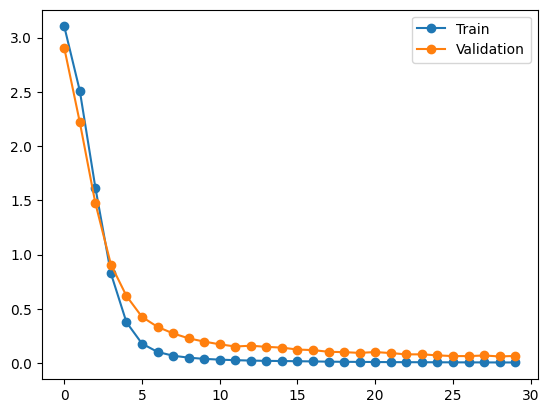

In [13]:
plt.plot(train_losses, marker='o', label="Train")
plt.plot(val_losses, marker='o', label="Validation")
plt.legend()

In [14]:
torch.save(model.state_dict(), "capcha_tiny.pt")

In [15]:
test_loss, test_acc = eval_epoch(model, test_loader, DEVICE)
print("TEST ACC:", test_acc)

TEST ACC: 0.96875


## Шаг 5: Инференес на примере из теста

In [16]:
from PIL import Image


@torch.inference_mode()
def predict_captcha(
    model: nn.Module,
    img: Image.Image,
    transform: T.Compose = transform,
    device: torch.device | str = DEVICE,
    idx2char: dict[int, str] = train_ds.idx2char
) -> str:

    model.eval()
    # Преобразуем изображение
    x = transform(img).unsqueeze(0).to(device)  # [1, 3, 64, 256]

    outputs = model(x)  # список из 5 тензоров [1, num_classes]
    preds = [torch.argmax(o, dim=1).item() for o in outputs]
    
    # Переводим индексы в символы
    predicted_chars = [idx2char[i] for i in preds]
    
    return "".join(predicted_chars)

In [17]:
im_test = Image.open("seminar_data/test/22d5n.png").convert("RGB")

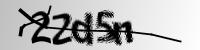

In [16]:
im_test

In [17]:
predict_captcha(model, im_test)

'22d5n'

### Шаг 6: теперь попробуем заморозить модель, оставив только N последних блоков

In [33]:
class ConvNeXtCaptcha(nn.Module):
    def __init__(
        self,
        num_classes: int = 36,
        num_heads: int = 5,
        backbone_size: Literal["tiny", "small"] = "tiny",
        num_blocks_freeze: int = 0  # Новый параметр = сколько слоев заморозим
    ):
        super().__init__()

        if backbone_size == "tiny":
            weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
            self.backbone = convnext_tiny(weights=weights)
        else:
            weights = ConvNeXt_Small_Weights.IMAGENET1K_V1
            self.backbone = convnext_small(weights=weights)

        # TODO: Переделать последние блоки под мультихэл
        # заменяем только последний linear

        in_features = self.backbone.classifier[2].in_features  # YOUR CODE HERE

        self.backbone.classifier[2] = nn.Identity()  # YOUR CODE HERE

        self.heads = nn.ModuleList([  # YOUR CODE HERE
            nn.Linear(in_features, num_classes) for _ in range(num_heads)
        ])

        # TODO: заморозить первые num_blocks_freeze внутр сети
        ## оставив обучаться только последние (число_блоков - num_blocks_freeze)
        for param in self.backbone.features[:num_blocks_freeze].parameters():
            param.requires_grad = False

    def forward(self, x: torch.Tensor) -> list[Tensor]:
        feats = self.backbone(x)
        return [head(feats) for head in self.heads]


In [34]:
model = ConvNeXtCaptcha(backbone_size = "tiny", num_blocks_freeze=6).to(DEVICE)
get_summary(model)

Всего параметров: 27,958,548
Обучаемых параметров: 15,610,548


In [35]:
%%time
optimizer = torch.optim.AdamW([
    {"params": model.backbone.parameters(), "lr": 3e-4},
    {"params": model.heads.parameters(), "lr": 1e-3}
])

val_losses = []
train_losses = []

for epoch in tqdm.tqdm(range(30)):
    train_loss= train_epoch(model, train_loader, optimizer, DEVICE)
    val_loss, val_acc = eval_epoch(model, val_loader, DEVICE)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"[{epoch}] train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

  3%|███▏                                                                                            | 1/30 [00:01<00:43,  1.49s/it]

[0] train_loss=3.0481 val_loss=2.9100 val_acc=0.0000


  7%|██████▍                                                                                         | 2/30 [00:02<00:39,  1.43s/it]

[1] train_loss=2.6256 val_loss=2.5693 val_acc=0.0000


 10%|█████████▌                                                                                      | 3/30 [00:04<00:38,  1.41s/it]

...

[27] train_loss=0.0332 val_loss=1.4644 val_acc=0.0469


 97%|███████████████████████████████████████████████████████████████████████████████████████████▊   | 29/30 [00:41<00:01,  1.41s/it]

[28] train_loss=0.0376 val_loss=1.4012 val_acc=0.0547


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:42<00:00,  1.43s/it]

[29] train_loss=0.0363 val_loss=1.4520 val_acc=0.0547
CPU times: user 35min 19s, sys: 1.77 s, total: 35min 21s
Wall time: 42.9 s


In [29]:
test_loss, test_acc = eval_epoch(model, test_loader, DEVICE)
print("TEST ACC:", test_acc)

TEST ACC: 0.11647727340459824


In [30]:
im_test = Image.open("seminar_data/test/22d5n.png").convert("RGB")
predict_captcha(model, im_test)

'2255m'

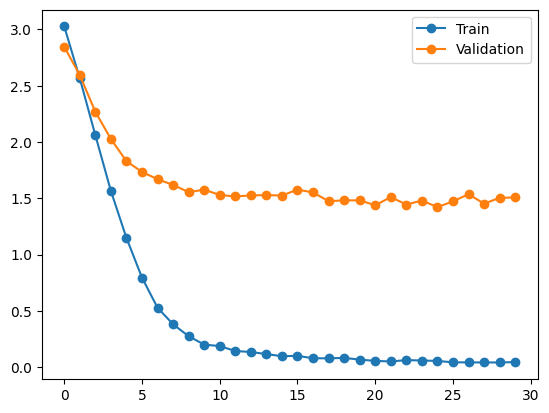

In [31]:
plt.plot(train_losses, marker='o', label="Train")
plt.plot(val_losses, marker='o', label="Validation")
plt.legend()

### Почему ничего не вышло?

На практике получаем:

- **Полный fine-tuning ConvNeXt** → хорошее обучение, нормальная валидация  
- **Partial freeze (заморожены 6 блоков)** → переобучение и плохая generalization  

При этом:
- число обучаемых параметров всё ещё большое
- оптимизация идёт стабильно
- loss уменьшается
- обучение "выглядит" корректным

Но качество на validation ухудшается.

**!ВАЖНО**

Partial freeze — это не регуляризация.  
Partial freeze — это жёсткое ограничение пространства признаков (representation space).

Что происходит:
- ранние слои жёстко зафиксированы
- они кодируют **ImageNet**-семантику (объекты, сцены, текстуры)
- CAPTCHA-домен требует **других признаков**:
  - контуры символов
  - локальные формы
  - пространственные паттерны
  - fine-grained детали

Dозникает **representation mismatch / representation bottleneck**
- важные признаки теряются
- нерелевантные признаки усиливаются
- модель не может изменить low-level фичи
- downstream-слои вынуждены работать с неподходящими признаками

Что она может сделать:
- запоминание соответствий
- табличное обучение
- подгонка под train
- отсутствие обобщения


**ImageNet → CAPTCHA = сильный domain shift**

- Partial freeze полезен, когда домены похожи.
- Partial freeze вреден, когда домены разные.


### Шаг 7 (Бонус): Попробуем в Mixed Precision

**Mixed Precision** — это техника, позволяющая обучать нейронные сети быстрее и с меньшим потреблением видеопамяти за счёт использования **float16** (half-precision) для части вычислений и **float32** (full-precision) там, где это критично.  

- GPU быстрее считает float16, чем float32.
- Уменьшается потребление VRAM.
- PyTorch сам выбирает, какие операции безопасно переводить в float16.
- Для обратного распространения используется **GradScaler**, чтобы градиенты не обнулялись.

#### Компоненты AMP в PyTorch:

1. `torch.cuda.amp.autocast()` — автоматически переключает вычисления в float16, где это безопасно.

3. `torch.cuda.amp.GradScaler()` — масштабирует градиенты для стабильного обучения.


#### 1. Как работает `autocast` в Mixed Precision

`autocast` **не переводит всю модель в float16 целиком**.  

- Он автоматически **переводит только безопасные операции** в float16.  
- Остальные операции остаются в float32, чтобы **не потерять точность**.  
- PyTorch использует внутренний список “безопасных” операций, например:
  - матричное умножение (`matmul`)
  - свёртки (`conv2d`)
  - некоторые активации (`ReLU`, `GELU`)

**Что переводится в float16:**

- Входные тензоры операций: например, результат свёртки или матричного умножения может автоматически стать float16.  
- Выход операции: тоже может быть float16, если операция безопасна.  

**Что не переводится**:

- Операции, где потеря точности критична:
  - softmax
  - layer normalization (LayerNorm)
  - batch normalization (BatchNorm)
  - суммирование больших чисел
- Веса (weights) обычно остаются float32, но на время конкретной операции могут быть приведены к float16.  


####  2. Как работает `GradScaler` в Mixed Precision

**Проблема float16**

- У float16 меньше разрядов для хранения чисел, чем у float32.  
- Если градиенты слишком маленькие, float16 **округляет их до нуля**.
    - float32: 0.00001234 → ок
    - float16: 0.00001234 → округляется до 0
- В результате шаг оптимизатора почти не меняет веса → обучение становится нестабильным.

**`GradScaler` решает эту проблему:**

1. Увеличивает градиенты перед backward:  
   - Умножает градиенты на большой коэффициент (scale factor)  
   - Маленькие градиенты становятся достаточно большими, чтобы float16 их точно хранить  

2. После шага оптимизатора делит обратно:
   - Обновление весов остаётся правильным  
   - Модель обучается корректно




In [36]:
def train_epoch_amp(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    scaler: GradScaler
) -> float:

    total_loss = 0.0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast():  # включаем mixed precision
            outputs = model(imgs)
            loss = compute_loss(outputs, labels)

        # масштабируем градиенты
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)

In [37]:
# берем полный файн-тюн tiny, как в первом эксперименте
model = ConvNeXtCaptcha(num_classes = len(train_ds.chars), backbone_size = "tiny").to(DEVICE)
get_summary(model)

# создаем скейлер один раз перед тренировкой
scaler = GradScaler()
# те же параметры, что были в первом эксперименте
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

Всего параметров: 27,958,548
Обучаемых параметров: 27,958,548


In [38]:
%%time

for epoch in tqdm.tqdm(range(30)):
    train_loss= train_epoch(model, train_loader, optimizer, DEVICE)
    val_loss, val_acc = eval_epoch(model, val_loader, DEVICE)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"[{epoch}] train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

  3%|███▏                                                                                            | 1/30 [00:02<01:00,  2.08s/it]

[0] train_loss=3.0797 val_loss=2.7342 val_acc=0.0000


  7%|██████▍                                                                                         | 2/30 [00:04<00:58,  2.07s/it]

[1] train_loss=2.3508 val_loss=2.0679 val_acc=0.0000


 10%|█████████▌                                                                                      | 3/30 [00:06<00:55,  2.07s/it]

...

[27] train_loss=0.0077 val_loss=0.0453 val_acc=0.9695


 97%|███████████████████████████████████████████████████████████████████████████████████████████▊   | 29/30 [00:59<00:02,  2.05s/it]

[28] train_loss=0.0058 val_loss=0.0455 val_acc=0.9616


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [01:01<00:00,  2.06s/it]

[29] train_loss=0.0049 val_loss=0.0439 val_acc=0.9695
CPU times: user 34min 5s, sys: 1.44 s, total: 34min 6s
Wall time: 1min 1s


In [40]:
test_loss, test_acc = eval_epoch(model, test_loader, DEVICE)
print("TEST ACC:", test_acc)
im_test = Image.open("seminar_data/test/22d5n.png").convert("RGB")
predict_captcha(model, im_test)

TEST ACC: 0.9765625


'22d5n'

### Шаг 8 (Бонус): EarlyStopping

In [41]:
class EarlyStopping:
    def __init__(self, patience: int = 3, min_delta: float = 0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
            return False

        if self.best_score - current_score > self.min_delta:
            self.best_score = current_score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

In [42]:
model = ConvNeXtCaptcha(num_classes = len(train_ds.chars), backbone_size = "tiny").to(DEVICE)
get_summary(model)

scaler = GradScaler()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

Всего параметров: 27,958,548
Обучаемых параметров: 27,958,548


In [44]:
%%time

early_stopper = EarlyStopping()

for epoch in tqdm.tqdm(range(50)):
    train_loss= train_epoch(model, train_loader, optimizer, DEVICE)
    val_loss, val_acc = eval_epoch(model, val_loader, DEVICE)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"[{epoch}] train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    if early_stopper(val_loss):
        print(f"Раннее прекращение на эпохе {epoch} (Val Loss не улучшался {early_stopper.patience} эпох)")
        break

  2%|█▉                                                                                              | 1/50 [00:02<01:46,  2.18s/it]

[0] train_loss=2.7009 val_loss=2.4273 val_acc=0.0000


  4%|███▊                                                                                            | 2/50 [00:04<01:40,  2.10s/it]

[1] train_loss=1.8374 val_loss=1.6329 val_acc=0.0540


  6%|█████▊                                                                                          | 3/50 [00:06<01:37,  2.07s/it]

...

[21] train_loss=0.0085 val_loss=0.0838 val_acc=0.9304


 46%|███████████████████████████████████████████▋                                                   | 23/50 [00:47<00:55,  2.07s/it]

[22] train_loss=0.0085 val_loss=0.0886 val_acc=0.9460


 46%|███████████████████████████████████████████▋                                                   | 23/50 [00:49<00:58,  2.17s/it]

[23] train_loss=0.0095 val_loss=0.0744 val_acc=0.9460
Раннее прекращение на эпохе 23 (Val Loss не улучшался 3 эпох)
CPU times: user 27min 41s, sys: 1.39 s, total: 27min 43s
Wall time: 49.9 s
